# Credit Cycle & Inventory Analysis for a Consumer Durables Distributor
## Part 1: Descriptive and core analysis
### Case study: Anuratna Corporation, Jaipur (authorised Sansui distributor)

**Author:** Bhavya Sharma, BS in Data Science & Applications, IIT Madras
**Context:** Business Data Management capstone project. Awarded Best Project.

---

## The business

Anuratna Corporation is a B2B distributor in Jaipur, Rajasthan. It buys Sansui **televisions and washing machines** and sells them to about **29 electronics and mobile retailers** across the city.

```
Sansui (brand)  ->  Anuratna Corporation (distributor)  ->  29 retail dealers in Jaipur  ->  consumers
   fixes prices        pays for stock up front,                 buy on 30-day credit
                       earns a thin margin (~6-8%)
```

Dealers buy on credit and officially have **30 days** to pay each invoice. The firm tracks payment in *credit cycles*: cycle 1 = days 1-30 (on time), cycle 2 = days 31-60, cycle 3 = days 61-90. Sansui fixes the price at which the distributor sells to retailers, so the firm can't compete on price.

## Problems raised by the proprietor

1. **Extended credit cycles:** dealers take 60-90+ days to pay, some never pay, and cash is always tight.
2. **Poor investment rotation:** money is tied up in stock that doesn't sell while popular models run short.
3. **Price wars:** competing brands undercut Sansui, and the firm has no control over price.

## What this notebook covers

1. Load and clean the data
2. Exploratory analysis: sales, payment times, open balances, receivables ageing, DSO
3. Payment behaviour by review period: dealer heatmap, credit-cycle breakdown, box plots
4. Dealer performance: persistent non-payers and payment patterns
5. Dealer segmentation (K-means)
6. A first late-payment prediction model (logistic regression)
7. Product demand: model-wise sales trends and seasonality
8. Price comparison with competitor brands
9. Conclusions, recommendations and open questions

[Part 2](anuratna_part2_advanced_revisit.ipynb) revisits these conclusions with more advanced methods.

> **Data:** the firm's data is confidential; this notebook is shown on a representative dataset that reproduces its summary figures.

| File | One row per | Key columns |
|---|---|---|
| `dealer_master.csv` | dealer (29) | dealer_code, dealer_name, area, dealing_since, credit_limit |
| `sales_invoices.csv` | invoice (Jan 2021 - Dec 2023) | invoice_no, invoice_date, dealer_code, invoice_amount, credit_days |
| `payment_receipts.csv` | payment received | receipt_no, invoice_no, receipt_date, amount_received, mode |
| `invoice_items.csv` | invoice line | invoice_no, model_code, category, qty, rate, amount |
| `product_master.csv` | model (18) | model_code, description, size, dealer_rate, distributor_margin_pct |
| `competitor_prices.csv` | brand x size | category, size, brand, dealer_landing_price |

**Terms used:** *receivables / sundry debtors* = money dealers owe for unpaid invoices; *ageing* = unpaid money grouped by how old the invoice is; *DSO (days sales outstanding)* = receivables divided by recent daily sales, i.e. roughly how many days of sales are sitting unpaid.

## 0. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 100
SEED = 42

In [2]:
# works on Kaggle, Colab (folder uploaded to /content) or locally
if os.path.exists('/kaggle/input/anuratna-distribution-data'):
    DATA = '/kaggle/input/anuratna-distribution-data'
elif os.path.exists('/content/anuratna-distribution-data'):
    DATA = '/content/anuratna-distribution-data'
else:
    DATA = 'input/anuratna-distribution-data'

for dirname, _, filenames in os.walk(DATA):
    for f in sorted(filenames):
        print(os.path.join(dirname, f))

input/anuratna-distribution-data/competitor_prices.csv
input/anuratna-distribution-data/dealer_master.csv
input/anuratna-distribution-data/invoice_items.csv
input/anuratna-distribution-data/payment_receipts.csv
input/anuratna-distribution-data/product_master.csv
input/anuratna-distribution-data/sales_invoices.csv


## 1. Load and clean the data

In [3]:
dealers   = pd.read_csv(f'{DATA}/dealer_master.csv')
invoices  = pd.read_csv(f'{DATA}/sales_invoices.csv')
receipts  = pd.read_csv(f'{DATA}/payment_receipts.csv')
items     = pd.read_csv(f'{DATA}/invoice_items.csv')
products  = pd.read_csv(f'{DATA}/product_master.csv')
comp      = pd.read_csv(f'{DATA}/competitor_prices.csv')

for name, df_ in [('dealers', dealers), ('invoices', invoices), ('receipts', receipts),
                  ('items', items), ('products', products), ('competitor prices', comp)]:
    print(f'{name:18s} {df_.shape}')

dealers            (29, 6)
invoices           (1231, 5)
receipts           (1045, 5)
items              (4073, 6)
products           (18, 7)
competitor prices  (62, 5)


In [4]:
invoices.head()

,invoice_no,invoice_date,dealer_code,invoice_amount,credit_days
0,AC/00002,03-01-2021,D04,39700,30
1,AC/00004,03-01-2021,D06,29900,30
2,AC/00009,05-01-2021,D13,9700,30
3,AC/00012,05-01-2021,D17,7200,30
4,AC/00016,07-01-2021,D22,27000,30


In [5]:
receipts.head()

,receipt_no,invoice_no,receipt_date,amount_received,mode
0,RC-00001,AC/00009,22-01-2021,9700,Cheque
1,RC-00002,AC/00008,23-01-2021,7200,NEFT
2,RC-00003,AC/00012,13-02-2021,7200,NEFT
3,RC-00004,AC/00016,23-02-2021,27000,Cheque
4,RC-00005,AC/00002,26-02-2021,39700,Cheque


In [6]:
print(invoices.isna().sum().sum(), 'missing values in invoices')
print(receipts.isna().sum().sum(), 'missing values in receipts')
print(invoices.invoice_no.duplicated().sum(), 'duplicate invoice numbers')
dups = receipts.duplicated(subset=['invoice_no', 'receipt_date', 'amount_received'])
print(dups.sum(), 'duplicate receipt rows (same invoice, date and amount)')
receipts[receipts.invoice_no.isin(receipts.loc[dups, 'invoice_no'])].sort_values('invoice_no')

0 missing values in invoices
0 missing values in receipts
0 duplicate invoice numbers
4 duplicate receipt rows (same invoice, date and amount)


,receipt_no,invoice_no,receipt_date,amount_received,mode
80,RC-00081,AC/00068,19-06-2021,17700,Cheque
81,RC-00082,AC/00068,19-06-2021,17700,Cheque
539,RC-00540,AC/00559,31-10-2022,32500,NEFT
540,RC-00541,AC/00559,31-10-2022,32500,NEFT
693,RC-00694,AC/00799,05-04-2023,83800,NEFT
694,RC-00695,AC/00799,05-04-2023,83800,NEFT
1005,RC-01006,AC/01013,31-01-2024,40000,NEFT
1007,RC-01008,AC/01013,31-01-2024,40000,NEFT


A few receipts were posted twice in the accounts. I drop the duplicates, then convert the dd-mm-yyyy dates from the Tally export.

In [7]:
receipts = receipts.drop_duplicates(subset=['invoice_no', 'receipt_date', 'amount_received'])
invoices['invoice_date'] = pd.to_datetime(invoices.invoice_date, dayfirst=True)
receipts['receipt_date'] = pd.to_datetime(receipts.receipt_date, dayfirst=True)

# each receipt should settle exactly one invoice in full
chk = receipts.merge(invoices, on='invoice_no')
assert len(chk) == len(receipts) and (chk.amount_received == chk.invoice_amount).all()
print('invoices from', invoices.invoice_date.min().date(), 'to', invoices.invoice_date.max().date())

invoices from 2021-01-03 to 2023-12-31


The debtors list was pulled on **29 Feb 2024**, so an invoice without a receipt by then is still unpaid. The firm reviews its sundry debtors in three periods, which I use throughout: **Apr'22-Oct'22, Nov'22-Mar'23 and Apr'23-Oct'23**.

In [8]:
SNAPSHOT = pd.Timestamp('2024-02-29')
PERIODS = {'P1': ('2022-04-01', '2022-10-31', "Apr'22-Oct'22"),
           'P2': ('2022-11-01', '2023-03-31', "Nov'22-Mar'23"),
           'P3': ('2023-04-01', '2023-10-31', "Apr'23-Oct'23")}
PLABEL = {k: v[2] for k, v in PERIODS.items()}

def period_of(d):
    for p, (s, e, _) in PERIODS.items():
        if pd.Timestamp(s) <= d <= pd.Timestamp(e):
            return p
    return 'other'

ledger = (invoices
          .merge(receipts[['invoice_no', 'receipt_date']], on='invoice_no', how='left')
          .merge(dealers, on='dealer_code'))
ledger['period'] = ledger.invoice_date.map(period_of)
ledger['paid'] = ledger.receipt_date.notna().astype(int)
ledger['days_to_pay'] = (ledger.receipt_date - ledger.invoice_date).dt.days
ledger = ledger.sort_values('invoice_date').reset_index(drop=True)

items = items.merge(invoices[['invoice_no', 'invoice_date', 'dealer_code']], on='invoice_no')
items['month'] = items.invoice_date.dt.to_period('M').dt.to_timestamp()
ledger[['invoice_no', 'invoice_date', 'dealer_name', 'invoice_amount', 'period', 'receipt_date', 'days_to_pay']].sample(6, random_state=1)

,invoice_no,invoice_date,dealer_name,invoice_amount,period,receipt_date,days_to_pay
1020,AC/01028,2023-08-20,Shree Salasar Electronics,103700,P3,2023-10-30,71.0
546,AC/00551,2022-08-25,Techno Tree,36300,P1,2022-10-02,38.0
854,AC/00864,2023-04-17,Parshav Electronics,62000,P3,2023-06-13,57.0
940,AC/00931,2023-06-15,Global Communication,114000,P3,2023-09-15,92.0
673,AC/00642,2022-11-26,"Ashoka Electronics, Shastri Nagar",39600,P2,2023-01-11,46.0
1189,AC/01199,2023-12-01,Deepanshi Electronics,39200,other,NaT,NaN


## 2. Exploratory analysis

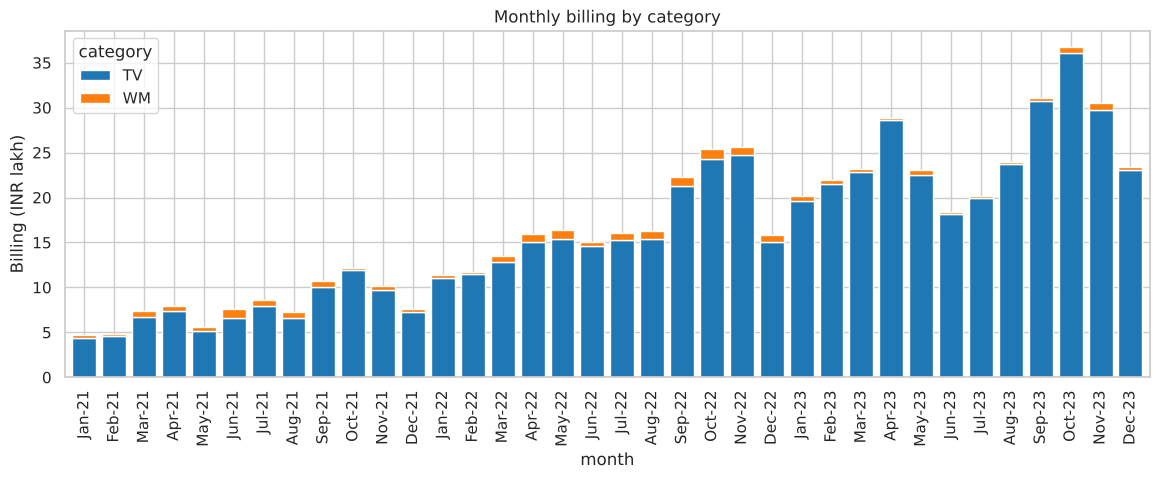

category,TV,WM,total,WM share %
invoice_date,,,,
2021,88.3,6.2,94.4,6.5
2022,196.4,9.1,205.5,4.4
2023,296.5,4.8,301.3,1.6


In [9]:
monthly_sales = items.pivot_table(index='month', columns='category', values='amount', aggfunc='sum').fillna(0) / 1e5
ax = monthly_sales.set_axis(monthly_sales.index.strftime('%b-%y')).plot(kind='bar', stacked=True, figsize=(14, 4.5), width=0.8)
ax.set_ylabel('Billing (INR lakh)')
ax.set_title('Monthly billing by category')
plt.show()

yearly = items.groupby([items.invoice_date.dt.year, 'category']).amount.sum().unstack() / 1e5
yearly['total'] = yearly.sum(axis=1)
yearly['WM share %'] = 100 * yearly.WM / yearly.total
yearly.round(1)

Billing roughly tripled, from INR 94 lakh in 2021 to INR 301 lakh in 2023, almost entirely from TVs, with clear peaks around the Sep-Nov festive season. Washing machines fell from 6.5% to 1.6% of billing.

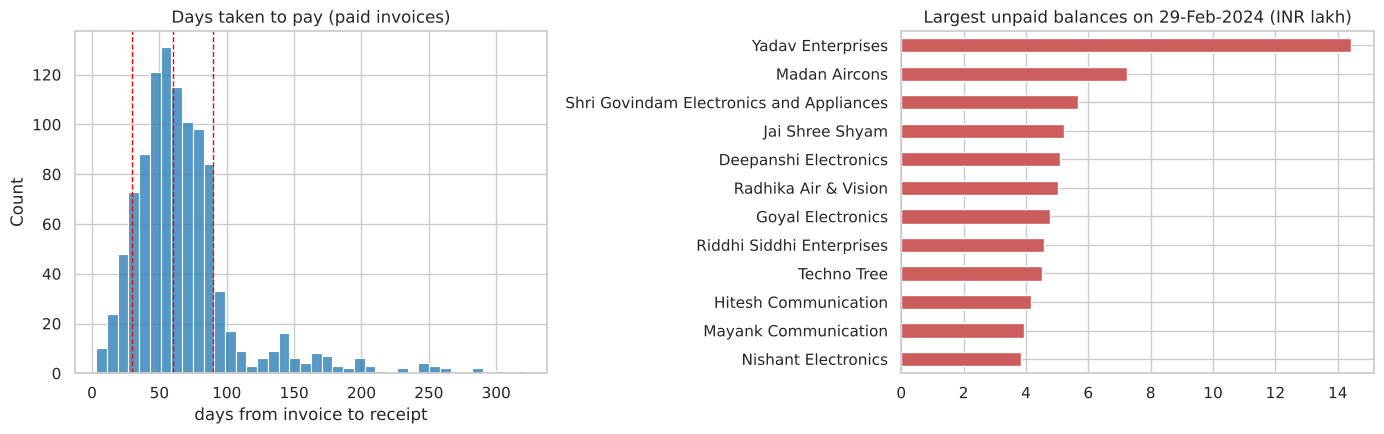

11.6% of paid invoices were paid within the 30-day terms
median days to pay (paid invoices): 60
190 invoices unpaid, INR 85.2 lakh


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
paid = ledger[ledger.paid == 1]
sns.histplot(paid.days_to_pay, bins=40, ax=axes[0])
for x in (30, 60, 90):
    axes[0].axvline(x, color='red', ls='--', lw=1)
axes[0].set_title('Days taken to pay (paid invoices)')
axes[0].set_xlabel('days from invoice to receipt')

unpaid = ledger[ledger.paid == 0]
top = unpaid.groupby('dealer_name').invoice_amount.sum().sort_values().tail(12) / 1e5
top.plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Largest unpaid balances on 29-Feb-2024 (INR lakh)')
axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

print(f'{(paid.days_to_pay <= 30).mean():.1%} of paid invoices were paid within the 30-day terms')
print(f'median days to pay (paid invoices): {paid.days_to_pay.median():.0f}')
print(f'{len(unpaid)} invoices unpaid, INR {unpaid.invoice_amount.sum()/1e5:.1f} lakh')

### Receivables ageing and DSO

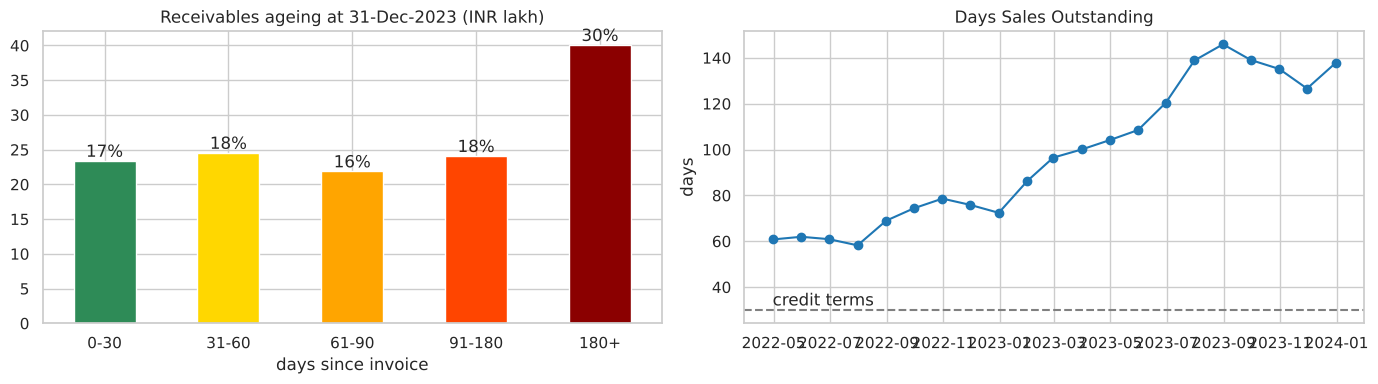

In [11]:
def ageing(asof):
    o = ledger[(ledger.invoice_date <= asof) & (ledger.receipt_date.isna() | (ledger.receipt_date > asof))].copy()
    o['age'] = (asof - o.invoice_date).dt.days
    o['bucket'] = pd.cut(o.age, [-1, 30, 60, 90, 180, 10_000], labels=['0-30', '31-60', '61-90', '91-180', '180+'])
    return o.groupby('bucket', observed=False).invoice_amount.sum()

age = ageing(pd.Timestamp('2023-12-31'))

rows = []
for m in pd.date_range('2022-04-30', '2023-12-31', freq='ME'):
    ar = ledger.loc[(ledger.invoice_date <= m) & (ledger.receipt_date.isna() | (ledger.receipt_date > m)), 'invoice_amount'].sum()
    s90 = ledger.loc[ledger.invoice_date.between(m - pd.Timedelta(days=89), m), 'invoice_amount'].sum()
    rows.append((m, ar / s90 * 90))          # DSO on trailing 90-day sales
dso = pd.DataFrame(rows, columns=['month', 'dso'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
(age / 1e5).plot(kind='bar', ax=axes[0], color=['seagreen', 'gold', 'orange', 'orangered', 'darkred'], rot=0)
axes[0].set_title('Receivables ageing at 31-Dec-2023 (INR lakh)'); axes[0].set_xlabel('days since invoice')
for i, v in enumerate(age / age.sum()):
    axes[0].text(i, age.iloc[i] / 1e5, f'{v:.0%}', ha='center', va='bottom')
axes[1].plot(dso.month, dso.dso, marker='o')
axes[1].axhline(30, color='grey', ls='--'); axes[1].text(dso.month.iloc[0], 32, 'credit terms')
axes[1].set_title('Days Sales Outstanding'); axes[1].set_ylabel('days')
plt.tight_layout(); plt.show()

Only about 12% of paid invoices were settled within the 30-day terms, and the median paid invoice took 60 days. INR 85 lakh was still unpaid on the snapshot date. DSO rose from about 60 days in mid-2022 to about 135 by the end of 2023, and nearly half the receivables were more than 90 days old. The credit cycle is getting longer, not shorter.

## 3. Payment behaviour by review period

For each review period, has the dealer cleared every invoice from that period?

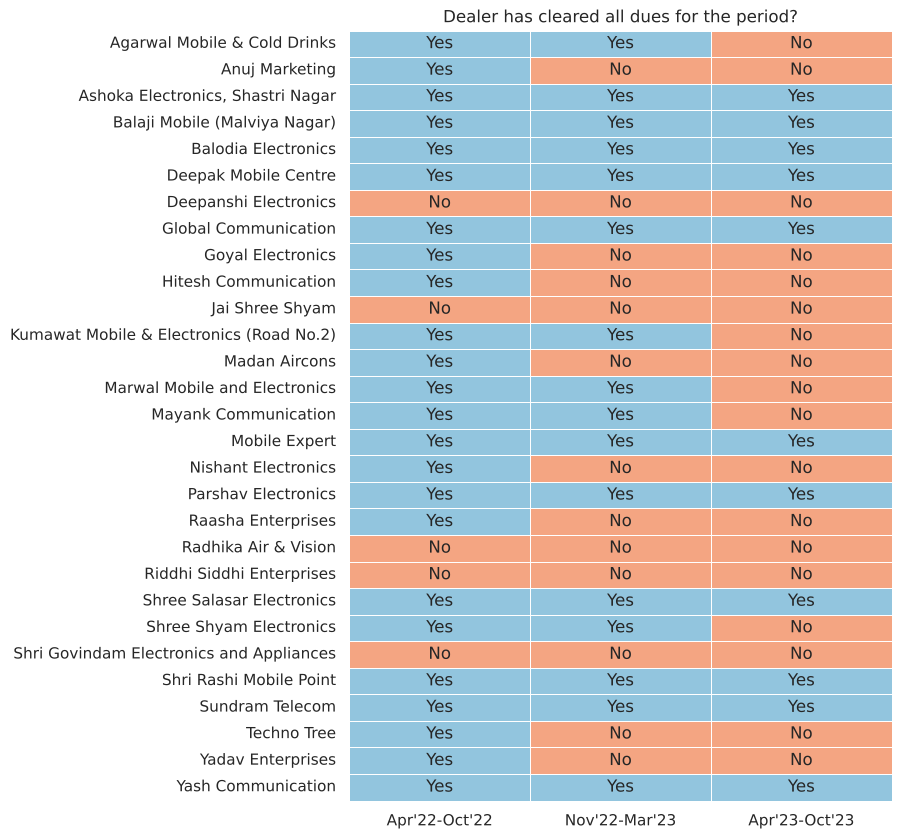

period
Apr'22-Oct'22    82.8
Nov'22-Mar'23    55.2
Apr'23-Oct'23    37.9
Name: % of dealers who cleared their dues, dtype: float64


In [12]:
rep = ledger[ledger.period.isin(PERIODS)]
settled = (rep.groupby(['dealer_name', 'period']).paid.min().unstack()   # 1 only if every invoice in the period is paid
              .rename(columns=PLABEL))

plt.figure(figsize=(7, 10))
sns.heatmap(settled, cmap=['#f4a582', '#92c5de'], cbar=False, linewidths=0.5, annot=settled.replace({1: 'Yes', 0: 'No'}), fmt='')
plt.title('Dealer has cleared all dues for the period?'); plt.ylabel(''); plt.xlabel('')
plt.show()
print((settled.mean() * 100).round(1).rename('% of dealers who cleared their dues'))

For dealers who did pay, how long did they take? I take each dealer's amount-weighted average days to pay in the period and place it in a credit cycle.

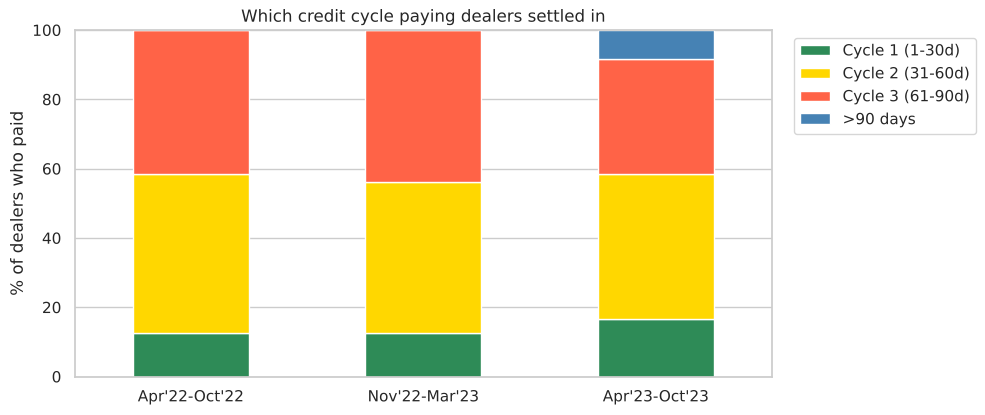

cycle,Cycle 1 (1-30d),Cycle 2 (31-60d),Cycle 3 (61-90d),>90 days
period,,,,
Apr'22-Oct'22,12.5,45.8,41.7,0.0
Nov'22-Mar'23,12.5,43.8,43.8,0.0
Apr'23-Oct'23,16.7,41.7,33.3,8.3


In [13]:
paid_rep = rep[rep.paid == 1]
dealer_days = paid_rep.groupby(['period', 'dealer_name']).apply(
    lambda g: np.average(g.days_to_pay, weights=g.invoice_amount), include_groups=False)
fully = settled.stack()
# dealers who cleared the period, plus Shree Shyam Electronics, which cleared most of its Apr-Oct'23 invoices
keep = [(p, d) for p, d in dealer_days.index if fully.get((d, PLABEL[p]), 0) == 1 or (p == 'P3' and d == 'Shree Shyam Electronics')]
dealer_days = dealer_days.loc[keep].rename('days').reset_index()
dealer_days['cycle'] = pd.cut(dealer_days.days, [0, 30, 60, 90, 1000],
                              labels=['Cycle 1 (1-30d)', 'Cycle 2 (31-60d)', 'Cycle 3 (61-90d)', '>90 days'])

cyc = (pd.crosstab(dealer_days.period.map(PLABEL), dealer_days.cycle, normalize='index') * 100).reindex(PLABEL.values())
cyc.plot(kind='bar', stacked=True, figsize=(9, 4.5), rot=0, color=['seagreen', 'gold', 'tomato', 'steelblue'])
plt.ylabel('% of dealers who paid'); plt.xlabel(''); plt.title('Which credit cycle paying dealers settled in')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.show()
cyc.round(1)

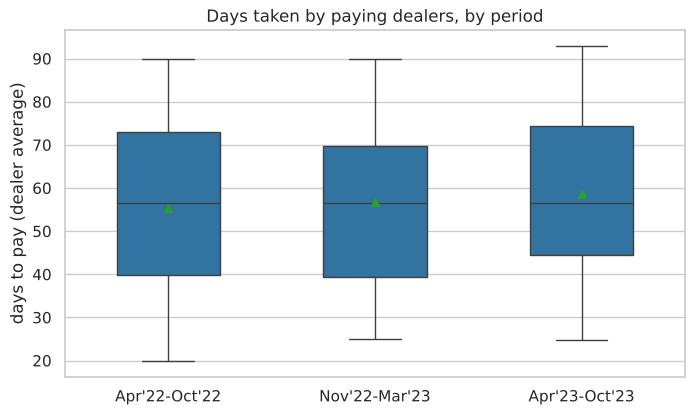

,dealers,Q1,median,Q3,mean,min,max
period,,,,,,,
Apr'22-Oct'22,24,39.22,56.52,74.90,55.28,19.95,89.98
Nov'22-Mar'23,16,37.90,56.44,75.25,56.81,25.07,89.98
Apr'23-Oct'23,12,43.63,56.56,74.90,58.53,24.86,92.98


In [14]:
def quartile_exc(x, q):
    # same definition as Excel's QUARTILE.EXC
    x = np.sort(np.asarray(x, float)); pos = q * (len(x) + 1) - 1; lo = int(np.floor(pos))
    return x[lo] + (pos - lo) * (x[lo + 1] - x[lo])

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=dealer_days, x=dealer_days.period.map(PLABEL), y='days', showmeans=True, width=0.5)
plt.xlabel(''); plt.ylabel('days to pay (dealer average)'); plt.title('Days taken by paying dealers, by period')
plt.show()

stats_tbl = dealer_days.groupby('period').days.agg(
    dealers='size', Q1=lambda v: quartile_exc(v, .25), median='median', Q3=lambda v: quartile_exc(v, .75),
    mean='mean', min='min', max='max').rename(index=PLABEL)
stats_tbl.round(2)

* The share of dealers who cleared all their dues fell from **82.8% to 55.2% to 37.9%** across the three periods.
* Among dealers who paid, only 12-17% settled within cycle 1. Most paid in cycle 2, and nearly all the rest in cycle 3.
* The median days to pay stayed at about **56.5 days** in every period (Q1 about 38-44, Q3 about 75). Paying dealers seem to pay at the same speed; the problem looks like more dealers not paying at all.

## 4. Dealer performance

In [15]:
s = settled.copy()
s.columns = ['P1', 'P2', 'P3']
groups = {
    'Never cleared dues (all 3 periods)': s.index[(s == 0).all(axis=1)],
    'Not cleared in the last 2 periods': s.index[(s.P1 == 1) & (s.P2 == 0) & (s.P3 == 0)],
    'Slipped only in the latest period': s.index[(s.P1 == 1) & (s.P2 == 1) & (s.P3 == 0)],
    'Cleared in every period': s.index[(s == 1).all(axis=1)],
}
for k, v in groups.items():
    print(f'{k} ({len(v)}): ' + ', '.join(v))

Never cleared dues (all 3 periods) (5): Deepanshi Electronics, Jai Shree Shyam, Radhika Air & Vision, Riddhi Siddhi Enterprises, Shri Govindam Electronics and Appliances
Not cleared in the last 2 periods (8): Anuj Marketing, Goyal Electronics, Hitesh Communication, Madan Aircons, Nishant Electronics, Raasha Enterprises, Techno Tree, Yadav Enterprises
Slipped only in the latest period (5): Agarwal Mobile & Cold Drinks, Kumawat Mobile & Electronics (Road No.2), Marwal Mobile and Electronics, Mayank Communication, Shree Shyam Electronics
Cleared in every period (11): Ashoka Electronics, Shastri Nagar, Balaji Mobile (Malviya Nagar), Balodia Electronics, Deepak Mobile Centre, Global Communication, Mobile Expert, Parshav Electronics, Shree Salasar Electronics, Shri Rashi Mobile Point, Sundram Telecom, Yash Communication


In [16]:
# outstanding exposure of the problem dealers
problem = list(groups['Never cleared dues (all 3 periods)']) + list(groups['Not cleared in the last 2 periods'])
exp = (unpaid[unpaid.dealer_name.isin(problem)].groupby('dealer_name')
       .agg(unpaid_invoices=('invoice_no', 'size'), unpaid_lakh=('invoice_amount', lambda x: x.sum() / 1e5),
            oldest_unpaid_days=('invoice_date', lambda d: (SNAPSHOT - d.min()).days))
       .sort_values('unpaid_lakh', ascending=False))
print(f'These {len(problem)} dealers hold INR {exp.unpaid_lakh.sum():.1f} lakh of the INR {unpaid.invoice_amount.sum()/1e5:.1f} lakh unpaid')
exp.round(2)

These 13 dealers hold INR 70.9 lakh of the INR 85.2 lakh unpaid


,unpaid_invoices,unpaid_lakh,oldest_unpaid_days
dealer_name,,,
Yadav Enterprises,23,14.44,473
Madan Aircons,15,7.25,470
Shri Govindam Electronics and Appliances,15,5.67,690
Jai Shree Shyam,17,5.21,670
Deepanshi Electronics,15,5.09,647
Radhika Air & Vision,17,5.04,685
Goyal Electronics,9,4.78,483
Riddhi Siddhi Enterprises,15,4.58,681
Techno Tree,9,4.50,424


Five dealers have not cleared their dues in any period, and eight more have not cleared them for the last two periods. Together these 13 dealers hold INR 70.9 lakh of the INR 85.2 lakh unpaid, much of it more than a year old. Five more slipped only in the latest period and need watching before they join the first group.

## 5. Dealer segmentation

To set credit terms per group, I cluster dealers with K-means on three payment features over Apr'22-Oct'23: average days to pay, share of invoices paid within 30 days, and share of review periods in which the dealer cleared all dues.

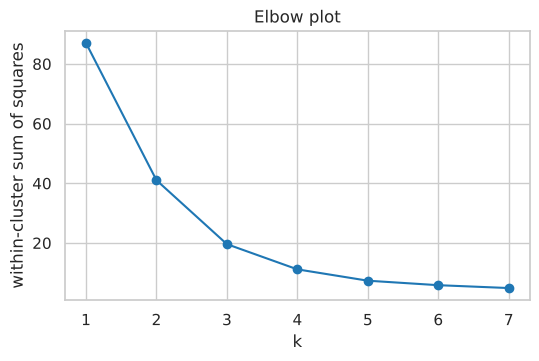

In [17]:
feat = rep.groupby('dealer_name').agg(
    avg_days=('days_to_pay', 'mean'),
    paid_within_30=('days_to_pay', lambda d: (d <= 30).sum()),
    n_invoices=('invoice_no', 'size'),
    billed_lakh=('invoice_amount', lambda x: x.sum() / 1e5))
feat['paid_within_30'] = feat.paid_within_30 / feat.n_invoices
feat['periods_cleared'] = settled.mean(axis=1)
feat['avg_days'] = feat.avg_days.fillna(feat.avg_days.max())
X = StandardScaler().fit_transform(feat[['avg_days', 'paid_within_30', 'periods_cleared']])

inertia = [KMeans(k, n_init=20, random_state=SEED).fit(X).inertia_ for k in range(1, 8)]
plt.figure(figsize=(6, 3.5)); plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('k'); plt.ylabel('within-cluster sum of squares'); plt.title('Elbow plot'); plt.show()

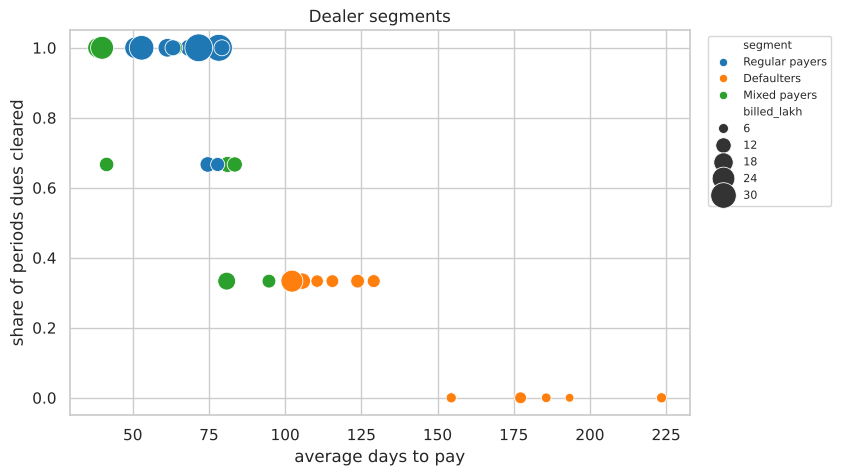

,dealers,avg_days,paid_within_30,periods_cleared,billed_lakh
segment,,,,,
Defaulters,11,147.36,0.01,0.18,102.93
Mixed payers,8,65.49,0.24,0.71,116.42
Regular payers,10,67.85,0.01,0.93,197.00


Regular payers: Agarwal Mobile & Cold Drinks, Ashoka Electronics, Shastri Nagar, Balodia Electronics, Deepak Mobile Centre, Global Communication, Marwal Mobile and Electronics, Mobile Expert, Shree Salasar Electronics, Shri Rashi Mobile Point, Yash Communication
Mixed payers: Balaji Mobile (Malviya Nagar), Kumawat Mobile & Electronics (Road No.2), Madan Aircons, Mayank Communication, Parshav Electronics, Shree Shyam Electronics, Sundram Telecom, Techno Tree
Defaulters: Anuj Marketing, Deepanshi Electronics, Goyal Electronics, Hitesh Communication, Jai Shree Shyam, Nishant Electronics, Raasha Enterprises, Radhika Air & Vision, Riddhi Siddhi Enterprises, Shri Govindam Electronics and Appliances, Yadav Enterprises


In [18]:
feat['cluster'] = KMeans(3, n_init=20, random_state=SEED).fit_predict(X)
prof = feat.groupby('cluster')[['avg_days', 'paid_within_30', 'periods_cleared', 'billed_lakh']].mean()
order = prof.periods_cleared.sort_values(ascending=False).index
names = dict(zip(order, ['Regular payers', 'Mixed payers', 'Defaulters']))
feat['segment'] = feat.cluster.map(names)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=feat, x='avg_days', y='periods_cleared', hue='segment', size='billed_lakh', sizes=(40, 400))
plt.xlabel('average days to pay'); plt.ylabel('share of periods dues cleared'); plt.title('Dealer segments')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8); plt.show()
display(feat.groupby('segment').agg(dealers=('cluster', 'size'), avg_days=('avg_days', 'mean'),
                                    paid_within_30=('paid_within_30', 'mean'), periods_cleared=('periods_cleared', 'mean'),
                                    billed_lakh=('billed_lakh', 'sum')).round(2))
for sname in ['Regular payers', 'Mixed payers', 'Defaulters']:
    print(f'{sname}: ' + ', '.join(feat.index[feat.segment == sname]))

Three groups:
* **Regular payers** (10 dealers, about half of billing) clear their dues in almost every period, but typically take about two months.
* **Mixed payers** (8) include the fastest dealers, who often pay within 30 days, alongside dealers who have started missing periods.
* **Defaulters** (11) have cleared their dues in fewer than one period in five, and when they do pay it takes around five months.

## 6. A first late-payment model

Can we flag invoices that will be paid late? Target: invoice **not paid within 60 days** (past credit cycle 2). Features: the dealer's average days to pay and share of invoices paid within 30 days, invoice amount, whether it was raised in the festive season (Sep-Nov), and how long the dealer has traded with the firm. Logistic regression with a 75/25 train/test split.

In [19]:
m = ledger[(SNAPSHOT - ledger.invoice_date).dt.days > 60].copy()      # label known for all of these
m['late60'] = (m.days_to_pay.isna() | (m.days_to_pay > 60)).astype(int)
dealer_stats = ledger.groupby('dealer_code').agg(dealer_avg_days=('days_to_pay', 'mean'),
                                                 dealer_share_30=('days_to_pay', lambda d: (d <= 30).mean()))
m = m.merge(dealer_stats, on='dealer_code')
m['dealer_avg_days'] = m.dealer_avg_days.fillna(m.dealer_avg_days.max())
m['log_amount'] = np.log(m.invoice_amount)
m['festive'] = m.invoice_date.dt.month.isin([9, 10, 11]).astype(int)
m['tenure'] = m.invoice_date.dt.year - m.dealing_since
features = ['dealer_avg_days', 'dealer_share_30', 'log_amount', 'festive', 'tenure']

X_tr, X_te, y_tr, y_te = train_test_split(m[features], m.late60, test_size=0.25, random_state=SEED, stratify=m.late60)
scaler = StandardScaler().fit(X_tr)
clf = LogisticRegression(max_iter=1000).fit(scaler.transform(X_tr), y_tr)
p_te = clf.predict_proba(scaler.transform(X_te))[:, 1]

print(f'{m.late60.mean():.0%} of invoices were paid late (after 60 days or not at all)')
print(f'accuracy {accuracy_score(y_te, p_te > 0.5):.3f} | ROC-AUC {roc_auc_score(y_te, p_te):.3f}')
print(classification_report(y_te, p_te > 0.5, target_names=['on time (<=60d)', 'late']))
pd.Series(clf.coef_[0], features).sort_values().round(3).rename('standardised coefficient')

57% of invoices were paid late (after 60 days or not at all)
accuracy 0.734 | ROC-AUC 0.799
                 precision    recall  f1-score   support

on time (<=60d)       0.72      0.61      0.66       132
           late       0.74      0.82      0.78       176

       accuracy                           0.73       308
      macro avg       0.73      0.72      0.72       308
   weighted avg       0.73      0.73      0.73       308



festive           -0.042
tenure             0.176
dealer_share_30    0.204
log_amount         0.585
dealer_avg_days    1.844
Name: standardised coefficient, dtype: float64

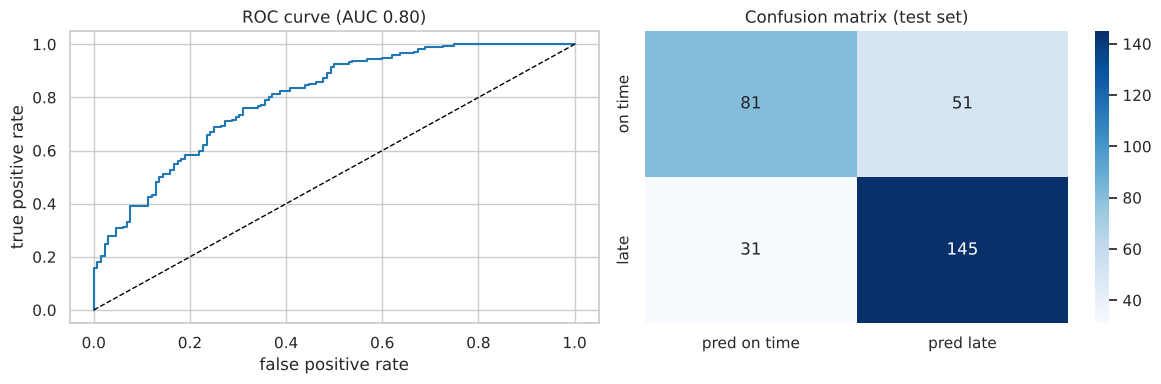

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fpr, tpr, _ = roc_curve(y_te, p_te)
axes[0].plot(fpr, tpr); axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title(f'ROC curve (AUC {roc_auc_score(y_te, p_te):.2f})'); axes[0].set_xlabel('false positive rate'); axes[0].set_ylabel('true positive rate')
sns.heatmap(confusion_matrix(y_te, p_te > 0.5), annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['pred on time', 'pred late'], yticklabels=['on time', 'late'])
axes[1].set_title('Confusion matrix (test set)')
plt.tight_layout(); plt.show()

The model reaches about 73% accuracy and a ROC-AUC of about 0.80 on the test set. The dealer's own average days to pay is by far the strongest predictor, and larger invoices are slightly more likely to be late. A dealer's history is a good guide to its next invoice, which supports setting credit terms per dealer.

## 7. Product demand

### 7.1 Model-wise sales, 2021-2023

In [21]:
units = items.pivot_table(index='model_code', columns=items.invoice_date.dt.year, values='qty', aggfunc='sum').fillna(0).astype(int)
units.columns = ['2021', '2022', '2023']
units['category'] = units.index.str[:2]
share = units.groupby('category')[['2021', '2022', '2023']].transform(lambda c: 100 * c / c.sum())
tbl = units.join(share.add_suffix(' share %'))

def label(r):
    if r['2021'] < r['2022'] < r['2023']: return 'Growing'
    if r['2021'] > r['2022'] > r['2023']: return 'Declining'
    return 'Fluctuating'
tbl['trend'] = tbl.apply(label, axis=1)
tbl.round(1)

,2021,2022,2023,category,2021 share %,2022 share %,2023 share %,trend
model_code,,,,,,,,
TV-JJSW55ASUHD,88,215,237,TV,12.6,14.1,10.0,Growing
TV-JSP90S-2022N,75,50,117,TV,10.8,3.3,4.9,Fluctuating
TV-JST32SKHD,23,130,190,TV,3.3,8.5,8.0,Growing
TV-JSW32ASHD,49,80,209,TV,7.0,5.2,8.8,Growing
TV-JSW32NSHD,76,100,193,TV,10.9,6.5,8.1,Growing
TV-JSW40ASFHD,45,165,211,TV,6.5,10.8,8.9,Growing
TV-JSW43ASFHD,35,45,172,TV,5.0,2.9,7.2,Growing
TV-JSY24NSHD,56,180,182,TV,8.0,11.8,7.7,Growing
TV-JSY24NSHD-A,68,210,205,TV,9.8,13.7,8.6,Fluctuating


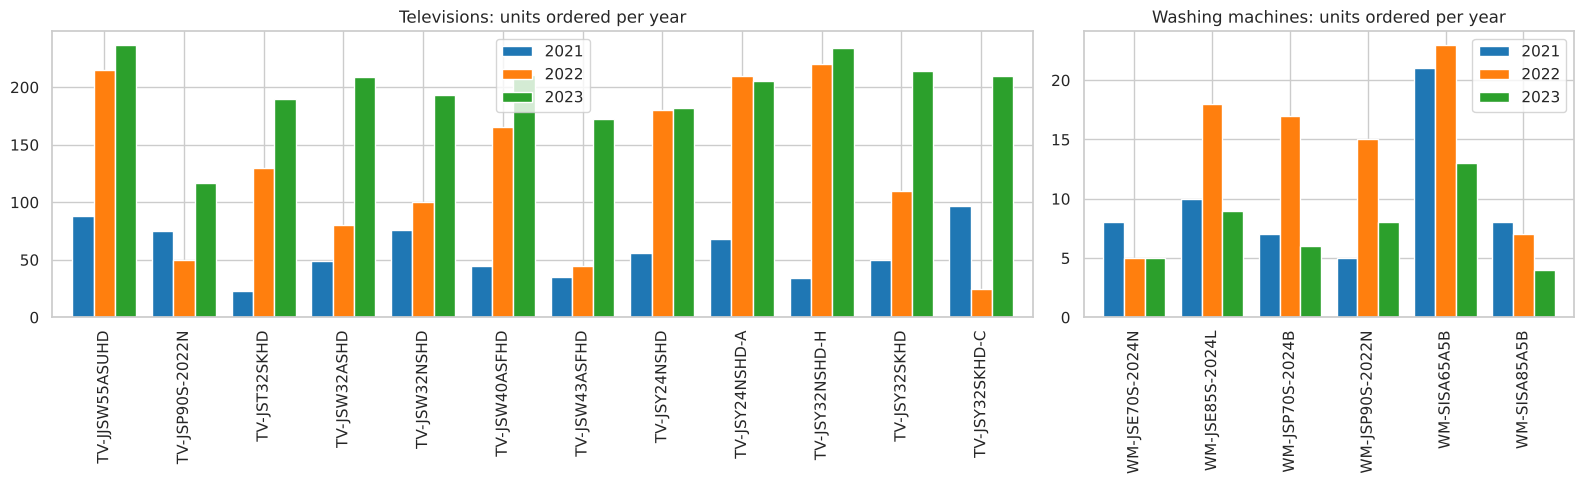

category  trend      
TV        Fluctuating    3
          Growing        9
WM        Declining      1
          Fluctuating    5
dtype: int64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})
units[units.category == 'TV'][['2021', '2022', '2023']].plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Televisions: units ordered per year'); axes[0].set_xlabel('')
units[units.category == 'WM'][['2021', '2022', '2023']].plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Washing machines: units ordered per year'); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()
print(tbl.groupby(['category', 'trend']).size())

### 7.2 Seasonality

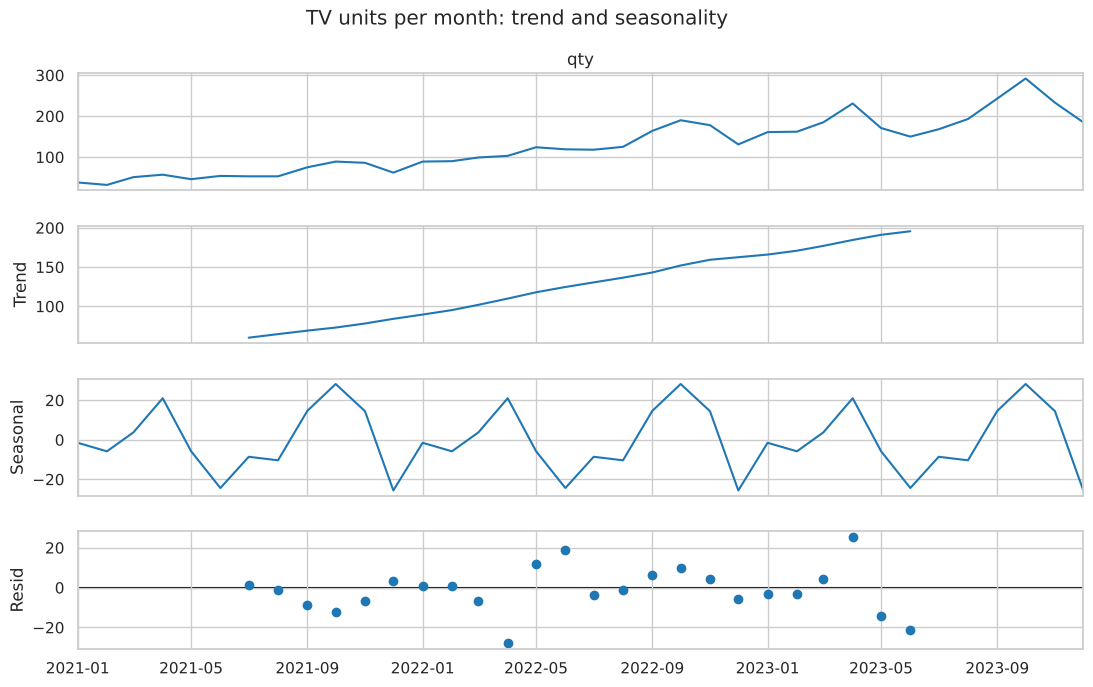

month
1     -1.5
2     -5.8
3      3.8
4     21.0
5     -5.8
6    -24.4
7     -8.6
8    -10.4
9     14.6
10    28.2
11    14.5
12   -25.6
Name: seasonal effect (units vs average month), dtype: float64


In [23]:
tv_monthly = items[items.category == 'TV'].groupby('month').qty.sum()
tv_monthly.index.freq = 'MS'
dec = seasonal_decompose(tv_monthly, model='additive', period=12)
fig = dec.plot(); fig.set_size_inches(12, 7); fig.suptitle('TV units per month: trend and seasonality', y=1.01); plt.show()
print((dec.seasonal.groupby(dec.seasonal.index.month).mean()).round(1).rename('seasonal effect (units vs average month)'))

* Nine of the twelve TV models grew every year and three fluctuated. JJSW55ASUHD, the 55-inch 4K model, is the largest by revenue.
* Washing machines are small and erratic: five of the six models fluctuate, and SISA85A5B declined every year.
* TV sales peak in Sep-Nov (festive season) and in April, and dip in June and December, so purchases should be planned ahead of those peaks.

## 8. Price comparison with competitors

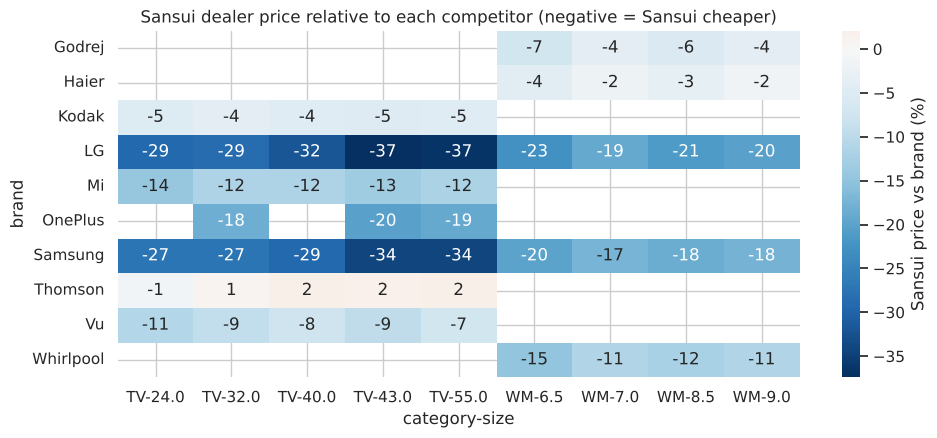

In [24]:
idx = comp.merge(comp[comp.brand == 'Sansui'][['category', 'size', 'dealer_landing_price']].rename(columns={'dealer_landing_price': 'sansui'}),
                 on=['category', 'size'])
idx['sansui_vs_brand_%'] = 100 * (idx.sansui / idx.dealer_landing_price - 1)
piv = idx[idx.brand != 'Sansui'].pivot_table(index='brand', columns=['category', 'size'], values='sansui_vs_brand_%')
plt.figure(figsize=(11, 4.5))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='RdBu_r', center=0, cbar_kws={'label': 'Sansui price vs brand (%)'})
plt.title('Sansui dealer price relative to each competitor (negative = Sansui cheaper)'); plt.show()

Sansui TVs are already 27-37% cheaper than Samsung and LG and within about 3% of the cheapest brand (Thomson) in every size; Sansui washing machines are the cheapest in every size. With Sansui also fixing the price, there is nothing for the distributor to gain on price. The levers it controls are credit terms and which models it keeps in stock.

## 9. Conclusions and recommendations

* **Credit:** payment discipline is weak and getting worse. Fewer dealers clear their dues each period, almost no one pays within 30 days, and 13 dealers hold most of the unpaid money.
* **Stock:** demand is growing for most TV models and is concentrated in the festive season. Washing machines are a small, erratic part of the business.
* **Price:** Sansui is already priced at or below its competitors, so price is not a lever.

### Recommendations

1. **Incentivise early payment:** offer a **3% discount** on invoices paid within credit cycle 1 (30 days). A discount within the first cycle is a clear, simple reward.
2. **Penalise late payment:** apply a **9% penalty** to dues not settled within the first credit cycle, in line with common trade practice, to recover the cost of delayed payments.
3. **Tighten follow-up on problem dealers:** intensive follow-up and written repayment plans for the dealers who have not cleared dues for two or more periods; stricter, clearly written credit terms for everyone.
4. **Reallocate stock investment:** put more of the stock budget into models with growing demand, and reduce stock of models with fluctuating or declining orders. Plan purchases around the September-November peak.
5. **Explore alternative financing,** such as invoice discounting or factoring, to ease the cash-flow pressure of long credit cycles.

### Open questions for further analysis

* The share of dealers who cleared their dues is lower for recent periods, but recent invoices have also had **less time** to be paid. How much of the drop is real?
* The box plots only include dealers who paid. Do they understate how slow payment really is?
* The late-payment model uses each dealer's average over the **whole** period, including payments made after the invoice being predicted, and a random split. Would it still work if it only used information available on the invoice date?
* The 3% discount and 9% penalty are not costed. Would they make or lose money once dealer behaviour and the cost of funds are considered?
* "Growing" models grew partly because the whole business grew. Which models are actually gaining ground?

[Part 2](anuratna_part2_advanced_revisit.ipynb) takes up these questions.